In [ ]:
from SystematicScanOfConvergence.MakeHam import *
# from Permutations.Helpers import *
from Permutations.Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from Permutations.SKQD import *
from Permutations.PowerSampling import *
from Permutations.CSRtoSPO import *
from BARK import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp
from new_approach.Hamiltonian_controlled_sparsity import make_controlled_sparse_ground_state_hamiltonian_from_qubits, make_controlled_sparse_ground_state_hamiltonian_fast
from new_approach.krab_4 import *

# Get Hamiltonian

### Approach One

In [2]:
# from SystematicScanOfConvergence.MakeHam import make_sparse_ground_state_hamiltonian_from_qubits

# H, psi, sup = make_sparse_ground_state_hamiltonian_from_qubits(8, 25, ground_energy=-5, gap =1, return_sparse=True)
# op = Operator(H.toarray())
# H_spo = SparsePauliOp.from_operator(op)
# correct_energy, correct_state = eigsh(H, k=1, which='SA')
# print(correct_energy)

### Approach Two

In [69]:
H, H_spo, psi, support, info = (
    make_controlled_sparse_ground_state_hamiltonian_fast(
        n_qubits=8,
        ground_state_sparsity=0.5,
        hamiltonian_sparsity=0.5,
        seed=123,
        ground_energy=-5,
        gap=1.0,
        return_info=True,
    )
)

## Initial State

In [70]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
sparsity = np.sum(amps > 1e-14) / len(amps)
print(f"Sparsity of the correct ground state: {sparsity:.4f}")
n_steps = 16
initial = np.argmax(amps)

initial_state = np.zeros(H.shape[0])
initial_state[initial] = 1

print(f"Initial overlap with correct state: {np.abs(np.dot(correct_state[:, 0].conj(), initial_state)):.4f}")
print(f'correct energy: {correct_energy}')

Sparsity of the correct ground state: 0.5039
Initial overlap with correct state: 0.2144
correct energy: [-5.]


In [71]:
initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')

# Bark

In [72]:
from new_approach.krab_4 import *

In [73]:
result = selected_krylov_ground_state(
    H=H,
    initial_bitstring=initial_bark,
    # Q=[600, 600, 600, 600, 100, 50],
    # Q=lambda app: max(50, int(600 * 0.95**app)),
    Q=10,
    delta=1e-8,
    epsilon=1e-6,
    n_iterations=30,
    max_subspace_dim=np.inf,
    score_mode="residual",
)

final_bitstrings = result.final_bitstrings

print("Final energy:", result.final_energy)
print("Final subspace size:", len(result.final_bitstrings))


Final energy: -5.000000000000004
Final subspace size: 129


In [74]:

def bitstrings_to_indices(basis: List[str]) -> List[int]:
    return [int(b, 2) for b in basis]

def get_one_path_from_BK(basis_list: List[str]) -> List[str]:
    energies = []
    for pos in tqdm.tqdm(range(len(basis_list))):
        current_basis = basis_list[:pos+1]
        indices = bitstrings_to_indices(current_basis)
        H_proj = project_down(H, indices)

        if pos > 2:
            energies.append(eigsh(H_proj, k=1, which='SA', return_eigenvectors=False)[0])
        else:
            energies.append(eigh(H_proj.toarray(), eigvals_only=True)[0])

    return energies

In [75]:
BK_BK_BK_path = get_one_path_from_BK(final_bitstrings)

100%|██████████| 129/129 [00:00<00:00, 477.04it/s]


# Get SKQD data

In [76]:
skqd_list0001 = do_skqd(H, n_steps, t = 0.001, initial=initial)
skqd_list001 = do_skqd(H, n_steps, t = 0.01, initial=initial)
skqd_list01 = do_skqd(H, n_steps, t = 0.1, initial=initial)
skqd_list02 = do_skqd(H, n_steps, t = 0.2, initial=initial)
skqd_list03 = do_skqd(H, n_steps, t = 0.3, initial=initial)
skqd_list04 = do_skqd(H, n_steps, t = 0.4, initial=initial)
skqd_list05 = do_skqd(H, n_steps, t = 0.5, initial=initial)
skqd_list06 = do_skqd(H, n_steps, t = 0.6, initial=initial)
skqd_list07 = do_skqd(H, n_steps, t = 0.7, initial=initial)
skqd_list08 = do_skqd(H, n_steps, t = 0.8, initial=initial)
skqd_list09 = do_skqd(H, n_steps, t = 0.9, initial=initial)
skqd_list10 = do_skqd(H, n_steps, t = 1.0, initial=initial)

100%|██████████| 16/16 [00:00<00:00, 844.54it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1125.87it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1208.30it/s]


...

No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1129.61it/s]


No more indices left to sample.


100%|██████████| 16/16 [00:00<00:00, 1027.92it/s]

No more indices left to sample.


In [77]:
skqd_path01 = get_one_path(H, skqd_list01)
skqd_path02 = get_one_path(H, skqd_list02)
skqd_path03 = get_one_path(H, skqd_list03)
skqd_path04 = get_one_path(H, skqd_list04)
skqd_path05 = get_one_path(H, skqd_list05)
skqd_path06 = get_one_path(H, skqd_list06)
skqd_path07 = get_one_path(H, skqd_list07)
skqd_path08 = get_one_path(H, skqd_list08)
skqd_path09 = get_one_path(H, skqd_list09)
skqd_path10 = get_one_path(H, skqd_list10)
skqd_path001 = get_one_path(H, skqd_list001)
skqd_path0001 = get_one_path(H, skqd_list0001)

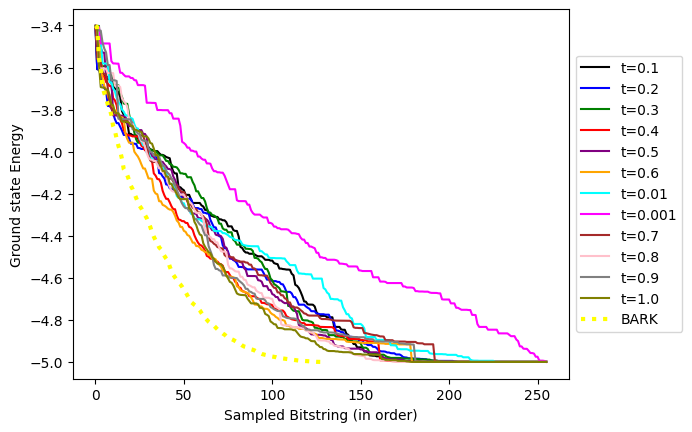

In [78]:
i = 0
# for path in Paths:
#     plt.plot(path, alpha=0.1)
#     i += 1
plt.plot(skqd_path01, label='t=0.1', color='black')
plt.plot(skqd_path02, label='t=0.2', color='blue')
plt.plot(skqd_path03, label='t=0.3', color='green')
plt.plot(skqd_path04, label='t=0.4', color='red')
plt.plot(skqd_path05, label='t=0.5', color='purple')
plt.plot(skqd_path06, label='t=0.6', color='orange')
plt.plot(skqd_path001, label='t=0.01', color='cyan')
plt.plot(skqd_path0001, label='t=0.001', color='magenta')
plt.plot(skqd_path07, label='t=0.7', color='brown')
plt.plot(skqd_path08, label='t=0.8', color='pink')
plt.plot(skqd_path09, label='t=0.9', color='gray')
plt.plot(skqd_path10, label='t=1.0', color='olive')
# plt.plot(power_path, label='Power Sampling', color='purple', linestyle='dashed')
# plt.plot(BK_path, label='BARK', color='purple', linestyle='dotted')
plt.plot(BK_BK_BK_path, label='BARK', color='yellow',linewidth=3.0, linestyle='dotted')
# Make legend next to plot
plt.ylabel('Ground state Energy')
plt.xlabel('Sampled Bitstring (in order)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
# after what bitstring do they reach a certain accuracy?

index_skqd = next((i for i, x in enumerate(skqd_path02) if abs(x + 5) < 0.001), None)

index_bark = next((i for i, x in enumerate(BK_BK_BK_path) if abs(x + 5) < 0.001), None)

print(index_skqd)
print(index_bark)

205
124


# Plotting

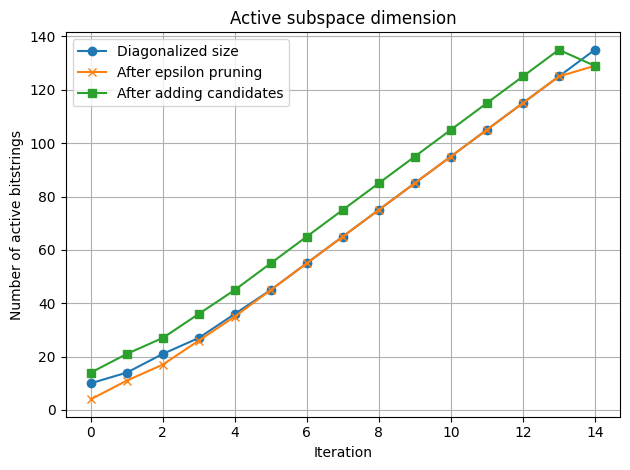

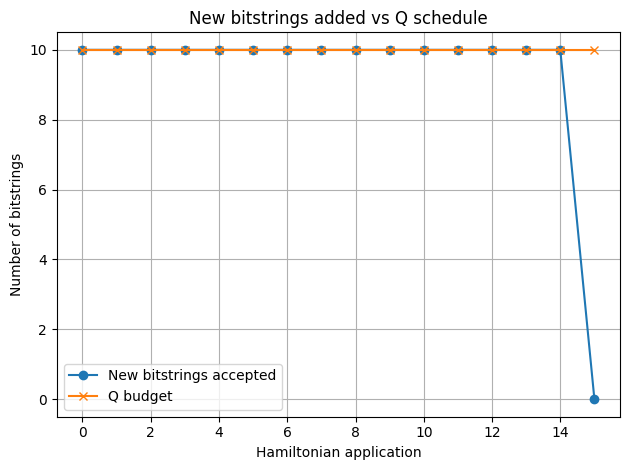

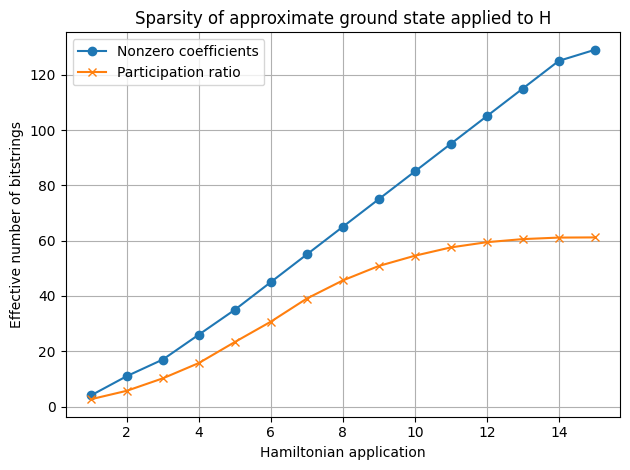

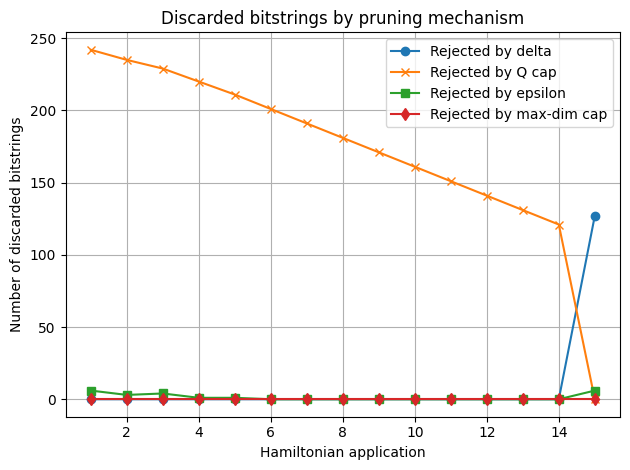

In [80]:
fig1, fig2, fig3, fig4 = plot_selected_krylov_diagnostics(result)
plt.show()